<a href="https://colab.research.google.com/github/LourdesBranchi/procesamiento-lenguaje-natural-1/blob/main/Desafio_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [ ]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, SimpleRNN, Embedding, Dropout
from keras.layers import TimeDistributed, CategoryEncoding
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.utils import pad_sequences

In [ ]:
import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16')

### Persistencia en Google Drive

Montamos Drive para guardar los modelos y el historial de perplejidad de cada arquitectura.
De esta forma, si el entorno se desconecta, los checkpoints quedan a salvo y no es necesario reentrenar.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
checkpoint_dir = '/content/drive/MyDrive/ceia_nlp_desafio3_v1'
os.makedirs(checkpoint_dir, exist_ok=True)

Mounted at /content/drive


### Datos
Utilizaremos como corpus la libros *"Cuentos de Amor de Locura y de Muerte"*, *"Anaconda y Otros Cuentos"* y *"Mas Alla y Otros Cuentos"*, los tres descargados de textos.info y usados también en el Desafio 2.

In [ ]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML
import bs4 as bs

In [ ]:
import requests
from bs4 import BeautifulSoup

def descargar_cuento(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")

    for tag in soup.find_all(["nav", "header", "footer", "script", "style"]):
        tag.decompose()

    parrafos = soup.find_all("p")
    return "\n".join(p.get_text(separator=" ", strip=True) for p in parrafos)


urls = [
    "https://www.textos.info/horacio-quiroga/cuentos-de-amor-de-locura-y-de-muerte/ebook",
    "https://www.textos.info/horacio-quiroga/anaconda-y-otros-cuentos/ebook",
    "https://www.textos.info/horacio-quiroga/mas-alla-y-otros-cuentos/ebook",
]

textos = []
for url in urls:
    texto = descargar_cuento(url)
    print(url, "->", len(texto), "caracteres")
    textos.append(texto)

article_text = "\n".join(textos).lower()
print(f"\nTotal de caracteres en el corpus: {len(article_text)}")
print("\nPrimeros 500 caracteres:\n", article_text[:500])

https://www.textos.info/horacio-quiroga/cuentos-de-amor-de-locura-y-de-muerte/ebook -> 290463 caracteres
https://www.textos.info/horacio-quiroga/anaconda-y-otros-cuentos/ebook -> 305750 caracteres
https://www.textos.info/horacio-quiroga/mas-alla-y-otros-cuentos/ebook -> 200180 caracteres

Total de caracteres en el corpus: 796395

Primeros 500 caracteres:
 
primavera
era el martes de carnaval. nébel acababa de entrar en el corso, ya al
oscurecer, y mientras deshacía un paquete de serpentinas, miró al
carruaje de delante. extrañado de una cara que no había visto la tarde
anterior, preguntó a sus compañeros:
—¿quién es? no parece fea.
—¡un demonio! es lindísima. creo que sobrina, o cosa así, del doctor arrizabalaga. llegó ayer, me parece…
nébel fijó entonces atentamente los ojos en la hermosa criatura. era
una chica muy joven aún, acaso no más d


### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [ ]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [ ]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto.
# usamos sorted() para garantizar un orden determinístico independientemente de la ejecución.
chars_vocab = sorted(set(article_text))

In [ ]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

73

In [ ]:
# Construimos los diccionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v, k in enumerate(chars_vocab)}
idx2char = {v: k for k, v in char2idx.items()}

In [ ]:
# guardamos los diccionarios en Drive para poder cargarlos si el entorno se reinicia
with open(f"{checkpoint_dir}/char2idx.pkl", "wb") as f:
    pickle.dump(char2idx, f)

with open(f"{checkpoint_dir}/idx2char.pkl", "wb") as f:
    pickle.dump(idx2char, f)

print("Diccionarios guardados.")

Diccionarios guardados.


###  Tokenizar

In [ ]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [ ]:
tokenized_text[:100]

[0,
 40,
 42,
 33,
 37,
 25,
 46,
 29,
 42,
 25,
 0,
 29,
 42,
 25,
 2,
 29,
 36,
 2,
 37,
 25,
 42,
 44,
 29,
 43,
 2,
 28,
 29,
 2,
 27,
 25,
 42,
 38,
 25,
 46,
 25,
 36,
 10,
 2,
 38,
 59,
 26,
 29,
 36,
 2,
 25,
 27,
 25,
 26,
 25,
 26,
 25,
 2,
 28,
 29,
 2,
 29,
 38,
 44,
 42,
 25,
 42,
 2,
 29,
 38,
 2,
 29,
 36,
 2,
 27,
 39,
 42,
 43,
 39,
 8,
 2,
 49,
 25,
 2,
 25,
 36,
 1,
 0,
 39,
 43,
 27,
 45,
 42,
 29,
 27,
 29,
 42,
 8,
 2,
 49,
 2,
 37,
 33,
 29,
 38,
 44]

### Organizando y estructurando el dataset

In [ ]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

In [ ]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val * max_context_size]
val_text = tokenized_text[-num_val * max_context_size:]

In [ ]:
# partimos val_text en bloques no superpuestos de tamaño max_context_size
tokenized_sentences_val = [val_text[init * max_context_size:(init + 1) * max_context_size] for init in range(num_val)]

In [ ]:
# para el conjunto de entrenamiento deslizamos una ventana de tamaño max_context_size
# con un stride > 1 para reducir la redundancia entre muestras consecutivas
stride = 3
tokenized_sentences_train = [train_text[init:init + max_context_size] for init in range(0, len(train_text) - max_context_size + 1, stride)]

In [ ]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

In [ ]:
print(f"Tamaño del conjunto de entrenamiento: {X.shape}")
print(f"Tamaño del vocabulario: {len(chars_vocab)}")

Tamaño del conjunto de entrenamiento: (238865, 100)
Tamaño del vocabulario: 73


In [ ]:
vocab_size = len(chars_vocab)

## Definiendo el modelo

El modelo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma los índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [ ]:
def build_model(rnn_layer, units=200, dropout=0.3, recurrent_dropout=0.3):
    """
    Construye un modelo Sequential intercambiando la celda recurrente.

    Args:
        rnn_layer (keras.layers): clase de la celda recurrente (SimpleRNN, LSTM o GRU)
        units (int): dimensión del estado oculto
        dropout (float): dropout sobre las conexiones de entrada
        recurrent_dropout (float): dropout sobre las conexiones recurrentes

    Returns:
        model (keras.Model): modelo compilado, listo para entrenar
    """
    model = Sequential()
    model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None, 1)))
    model.add(rnn_layer(units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout))
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [ ]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, patience=5, model_path="my_model.keras", history_path=None):
        self.val_data = val_data
        self.model_path = model_path
        self.history_path = history_path
        self.history_ppl = history_ppl

        self.target = []
        self.padded = []

        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience

        # nos movemos en todas las secuencias de los datos de validación
        for seq in self.val_data:
            len_seq = len(seq)
            # armamos todas las subsecuencias
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])

            if len(subseq) != 0:
                self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))
                self.info.append((count, count + len(subseq)))
                count += len(subseq)

        self.padded = np.vstack(self.padded)
        self.target = np.array(self.target)

    def on_epoch_end(self, epoch, logs=None):

        predictions = self.model.predict(self.padded, verbose=0)

        # extraemos de una vez la probabilidad asignada al token correcto en cada posición
        last_step_probs = predictions[:, -1, :]
        correct_probs = last_step_probs[np.arange(len(self.target)), self.target] + 1e-10
        log_probs = np.log(correct_probs)

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = [np.exp(-np.mean(log_probs[start:end])) for start, end in self.info]

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # persistimos el historial en Drive en cada epoch
        if self.history_path is not None:
            with open(self.history_path, "wb") as f:
                pickle.dump(self.history_ppl, f)

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.model_path)
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True


### Entrenamiento

Entrenamos tres variantes del mismo modelo manteniendo todos los hiperparámetros iguales y cambiando únicamente la celda recurrente: `SimpleRNN`, `LSTM` y `GRU`. Esto permite comparar de forma controlada cómo cada arquitectura impacta en la velocidad de convergencia y en la perplejidad final sobre el conjunto de validación.

In [ ]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl_simplernn = []
model_simplernn = build_model(SimpleRNN)
model_simplernn.summary()

hist_simplernn = model_simplernn.fit(
    X, y,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_simplernn, patience=5,
                            model_path=f"{checkpoint_dir}/model_simplernn.keras",
                            history_path=f"{checkpoint_dir}/history_ppl_simplernn.pkl")],
    batch_size=256
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 73)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        54,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 73)       │        14,673 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,473 (271.38 KB)

 Trainable params: 69,473 (271.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.1073
 mean perplexity: 24.421875 

Saved new model!
934/934 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - loss: 3.0569
Epoch 2/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.0163
 mean perplexity: 24.78125 

934/934 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 3.0090
Epoch 3/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.9945
 mean perplexity: 25.40625 

934/934 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 2.9914
Epoch 4/30
933/934 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.9828
 mean perplexity: 25.9375 

934/934 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 2.9802
Epoch 5/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.9724
 mean perplexity: 26.453125 

934/934 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - loss: 2.9700
Epoch 6/30
932/934 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.9627
 mean perplexity: 26.3125 

Stopping training...
934/934 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 2.9599


In [ ]:
history_ppl_lstm = []
model_lstm = build_model(LSTM)
model_lstm.summary()

hist_lstm = model_lstm.fit(
    X, y,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_lstm, patience=5,
                            model_path=f"{checkpoint_dir}/model_lstm.keras",
                            history_path=f"{checkpoint_dir}/history_ppl_lstm.pkl")],
    batch_size=256
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 73)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       219,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 73)       │        14,673 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,873 (913.57 KB)

 Trainable params: 233,873 (913.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - loss: 3.1118
 mean perplexity: 23.59375 

Saved new model!
934/934 ━━━━━━━━━━━━━━━━━━━━ 506s 530ms/step - loss: 3.0472
Epoch 2/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 2.9906
 mean perplexity: 24.671875 

934/934 ━━━━━━━━━━━━━━━━━━━━ 487s 522ms/step - loss: 2.9834
Epoch 3/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 2.9671
 mean perplexity: 25.375 

934/934 ━━━━━━━━━━━━━━━━━━━━ 503s 523ms/step - loss: 2.9629
Epoch 4/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 2.9512
 mean perplexity: 26.15625 

934/934 ━━━━━━━━━━━━━━━━━━━━ 487s 522ms/step - loss: 2.9470
Epoch 5/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 2.9349
 mean perplexity: 27.28125 

934/934 ━━━━━━━━━━━━━━━━━━━━ 487s 521ms/step - loss: 2.9314
Epoch 6/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 2.9204
 mean perplexity: 28.75 

Stopping training...
934/934 ━━━━━━━━━━━━━━━━━━━━ 490s 525ms/step - loss: 2.9171


In [ ]:
history_ppl_gru = []
model_gru = build_model(GRU)
model_gru.summary()

hist_gru = model_gru.fit(
    X, y,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_gru, patience=5,
                            model_path=f"{checkpoint_dir}/model_gru.keras",
                            history_path=f"{checkpoint_dir}/history_ppl_gru.pkl")],
    batch_size=256
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 73)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       165,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 73)       │        14,673 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,673 (701.85 KB)

 Trainable params: 179,673 (701.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - loss: 3.1037
 mean perplexity: 24.8125 

Saved new model!
934/934 ━━━━━━━━━━━━━━━━━━━━ 481s 509ms/step - loss: 3.0206
Epoch 2/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - loss: 2.9654
 mean perplexity: 25.96875 

934/934 ━━━━━━━━━━━━━━━━━━━━ 472s 505ms/step - loss: 2.9576
Epoch 3/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 2.9336
 mean perplexity: 28.28125 

934/934 ━━━━━━━━━━━━━━━━━━━━ 471s 504ms/step - loss: 2.9246
Epoch 4/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - loss: 2.8989
 mean perplexity: 29.296875 

934/934 ━━━━━━━━━━━━━━━━━━━━ 469s 502ms/step - loss: 2.8919
Epoch 5/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - loss: 2.8724
 mean perplexity: 30.921875 

934/934 ━━━━━━━━━━━━━━━━━━━━ 470s 504ms/step - loss: 2.8670
Epoch 6/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - loss: 2.8512
 mean perplexity: 31.203125 

Stopping training...
934/934 ━━━━━━━━━━━━━━━━━━━━ 469s 502ms/step - loss: 2.8461


### Comparación de perplejidad por arquitectura

In [ ]:
# si el entorno se reinició, cargar los historiales desde Drive
with open(f"{checkpoint_dir}/history_ppl_simplernn.pkl", "rb") as f:
    history_ppl_simplernn = pickle.load(f)

with open(f"{checkpoint_dir}/history_ppl_lstm.pkl", "rb") as f:
    history_ppl_lstm = pickle.load(f)

with open(f"{checkpoint_dir}/history_ppl_gru.pkl", "rb") as f:
    history_ppl_gru = pickle.load(f)

print(f"SimpleRNN: {len(history_ppl_simplernn)} épocas, mejor = {min(history_ppl_simplernn):.4f}")
print(f"LSTM:      {len(history_ppl_lstm)} épocas, mejor = {min(history_ppl_lstm):.4f}")
print(f"GRU:       {len(history_ppl_gru)} épocas, mejor = {min(history_ppl_gru):.4f}")

SimpleRNN: 6 épocas, mejor = 24.4219
LSTM:      6 épocas, mejor = 23.5938
GRU:       6 épocas, mejor = 24.8125


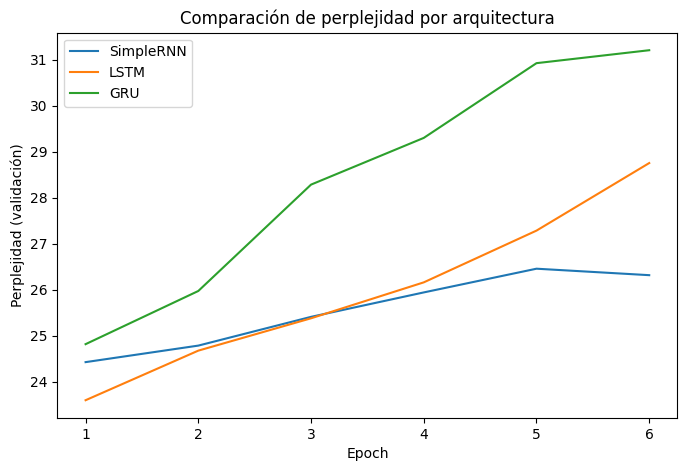

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(1, len(history_ppl_simplernn) + 1), y=history_ppl_simplernn, label="SimpleRNN")
sns.lineplot(x=range(1, len(history_ppl_lstm) + 1), y=history_ppl_lstm, label="LSTM")
sns.lineplot(x=range(1, len(history_ppl_gru) + 1), y=history_ppl_gru, label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Perplejidad (validación)")
plt.title("Comparación de perplejidad por arquitectura")
plt.legend()
plt.show()

Los tres modelos alcanzan su mejor perplejidad de validación en la época 1 (SimpleRNN: 24.42, LSTM: 23.59, GRU: 24.81) y en las épocas siguientes la perplejidad sube monotónicamente, lo que indica overfitting. El early stopping intervino en todos los casos alrededor de la época 6, no por convergencia sino porque la validación no dejaba de empeorar. En ese sentido, ninguna arquitectura logró entrenar de manera estable más allá de la primera época.



El LSTM obtuvo la menor perplejidad de validación, seguido de SimpleRNN y GRU, lo cual es parcialmente consistente con la teoría: se esperaría que LSTM y GRU superen a SimpleRNN en dependencias largas gracias a sus mecanismos de memoria. Sin embargo, el margen entre las tres es pequeño, lo que sugiere que el corpus de Quiroga elegido es demasiado reducido para que las diferencias arquitectónicas se manifiesten con claridad. Con un dataset pequeño, todos los modelos tienden a memorizar rápidamente el conjunto de entrenamiento sin generalizar, limitando el beneficio de arquitecturas más complejas como LSTM y GRU.

Cabe mencionar que se exploraron distintas configuraciones de hiperparámetros (tamaño de batch, número de unidades, longitud de secuencias) con el objetivo de mejorar la performance y lograr un entrenamiento más estable. Sin embargo, las limitaciones de cómputo disponibles en Colab, en particular el límite de uso de GPU gratuita, impidieron realizar experimentos más extensos. En todos los casos el comportamiento fue el mismo: overfitting temprano y early stopping antes de la época 10. Un corpus más grande o más épocas de entrenamiento con regularización más agresiva (mayor dropout, weight decay) probablemente permitirían que las diferencias entre arquitecturas se expresen con mayor claridad.

### Carga del mejor modelo

Si el entorno se reinició, correr esta celda carga los historiales desde Drive antes de elegir el mejor modelo.

In [ ]:
# si el entorno se reinició, cargar los diccionarios desde Drive
with open(f"{checkpoint_dir}/char2idx.pkl", "rb") as f:
    char2idx = pickle.load(f)

with open(f"{checkpoint_dir}/idx2char.pkl", "rb") as f:
    idx2char = pickle.load(f)

vocab_size = len(char2idx)
print(f"Vocabulario cargado: {vocab_size} caracteres")

Vocabulario cargado: 73 caracteres


In [ ]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
best_ppl = {
    "model_simplernn.keras": min(history_ppl_simplernn) if history_ppl_simplernn else np.inf,
    "model_lstm.keras":      min(history_ppl_lstm)      if history_ppl_lstm      else np.inf,
    "model_gru.keras":       min(history_ppl_gru)       if history_ppl_gru       else np.inf,
}

best_model_path = min(best_ppl, key=best_ppl.get)
print(f"Mejor modelo: {best_model_path} (perplejidad = {best_ppl[best_model_path]:.2f})")

model = keras.models.load_model(f"{checkpoint_dir}/{best_model_path}")

Mejor modelo: model_lstm.keras (perplejidad = 23.59)


### Generación de secuencias

In [ ]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [ ]:
input_text = 'habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=100)

'habia una vez                                                                                                    '

La generación mediante greedy search (selección del carácter de mayor probabilidad en cada paso) produce malos resultados: a partir de la semilla "había una vez", el modelo genera únicamente espacios en blanco. Esto es una consecuencia directa del overfitting temprano observado durante el entrenamiento: el modelo aprendió que el espacio es el carácter más frecuente en el corpus y lo asigna como el más probable en practicamente cualquier contexto. Esto ilustra una limitación fundamental del greedy search: al no introducir aleatoriedad en la selección, amplifica los sesgos aprendidos por el modelo, colapsando la generación hacia el token dominante. Este comportamiento motiva el uso de estrategias de sampleo con temperatura, que redistribuyen las probabilidades para permitir una generación más variada.

###  Beam search y muestreo aleatorio

In [ ]:
# funcionalidades para hacer encoding y decoding

def encode(text, max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [ ]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx, pp in enumerate(pred):
    pred_large.extend(np.log(pp + 1E-10) + history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large / temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select // vocab_size],
                        np.array([idx_select % vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1, mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words - 1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i + 1:]]).copy()

        # predicción
        y_hat = model.predict(input_update, verbose=0)[0, -1, :]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:, -(len(input) + num_words):]

In [ ]:
seed = "habia una vez"
num_beams = 10
num_words = 100

print("=== Greedy search ===")
print(generate_seq(model, seed, max_length=max_context_size, n_words=num_words))
print()

print("=== Beam search determinístico ===")
salidas_det = beam_search(model, num_beams=num_beams, num_words=num_words, input=seed, mode='det')
print(decode(salidas_det[0]))
print()

for temp in [0.3, 0.7, 1.0, 1.5, 2.0]:
    print(f"=== Beam search estocástico (temperatura = {temp}) ===")
    salidas_sto = beam_search(model, num_beams=num_beams, num_words=num_words, input=seed, temp=temp, mode='sto')
    print(decode(salidas_sto[0]))
    print()

=== Greedy search ===
habia una vez                                                                                                    

=== Beam search determinístico ===
habia una vez   eaaaa   eaaaa   eaaa   eaaa   eaaa   eaaaa   eaaaa   eaaa   eaaaa   eaaaa   eaaa   eaaaa   eaaa  

=== Beam search estocástico (temperatura = 0.3) ===
habia una vez         eeaaa   eeaa    eeaa      raa   eeaaa   eaaa    eeaa   seaa   eaaaa     eaaa        raaa  e

=== Beam search estocástico (temperatura = 0.7) ===
habia una veza   rra   eoeaea  eaoeaeu eeae    eaa   eaea    r    aeaai   raaaaeaaa   eaar eaen   sei    aaa   nn

=== Beam search estocástico (temperatura = 1.0) ===
habia una vezaean  moei   meaee eaea eaoaeeeoa   eoaa   teosn see  u   ei eaoeee       sioe   soeo     eaia n rae

=== Beam search estocástico (temperatura = 1.5) ===
habia una vezo r ldal  raaaeeer sviooa  eoeao el  saasrc   lri euaeepa or n eaaac c  peonelar scr d  ba ro  ereo

=== Beam search estocástico (temperatura = 2.0

Los resultados de generación reflejan claramente el impacto de cada estrategia y del valor de temperatura. El greedy search y el beam search determinístico colapsan hacia patrones repetitivos de espacios y vocales ("eaaaa"), confirmando que el modelo sobreajustado asigna probabilidades dominantes a los caracteres más frecuentes del corpus. A medida que se incrementa la temperatura en el beam search estocástico, la distribución se aplana y la generación se vuelve progresivamente más variada: con temperatura 0.3 y 0.7 siguen dominando las vocales y los espacios aunque con algo más de variedad, mientras que con temperatura 1.0 y 1.5 empiezan a aparecer consonantes y combinaciones más diversas. Con temperatura 2.0 el texto ya incorpora signos de puntuación y tildes, acercándose superficialmente a texto en español, aunque sin coherencia semántica ni sintáctica real. Ninguna configuración logra generar texto legible, lo cual es esperable dado el overfitting severo del modelo. La calidad de la generación está fundamentalmente limitada por la calidad del modelo entrenado, y ninguna estrategia de sampleo puede compensar esa limitación.